# KNN Regression Data (NO<sub>2</sub> Semarang)

K-Nearest Neighbors (KNN) Regression adalah salah satu metode dalam machine learning yang melakukan prediksi berdasarkan kedekatan data baru dengan beberapa data historis yang mirip. Pada proses prediksi, algoritma akan mencari K data terdekat (nearest neighbors) lalu menghitung rata-rata dari nilai target pada tetangga tersebut sebagai hasil prediksi.

Dalam konteks kasus prediksi NO₂, nilai lag (misalnya NO₂ dua hari sebelumnya hingga lima hari sebelumnya) digunakan sebagai fitur yang menggambarkan kondisi historis. KNN kemudian akan mencari periode di masa lalu yang memiliki pola lag yang mirip, lalu memprediksi kadar NO₂ besok dengan mengambil rata-rata kadar NO₂ yang terjadi pada periode-periode yang mirip tersebut.



# Mengapa R-Squared dan MSE Rendah pada Eksperimen?

R-Squared yang rendah menunjukkan bahwa variasi kadar NO₂ besok tidak cukup dapat dijelaskan hanya dengan data lag 2–5 hari sebelumnya. Hal ini masuk akal karena variabel lingkungan yang sangat memengaruhi kadar NO₂ tidak dimasukkan sebagai fitur dalam model. Dengan demikian, KNN hanya "menebak" dari pola serupa di masa lalu menggunakan informasi yang sangat terbatas.

# Modeling Data NO<sub>2</sub> Semarang

Dalam modeling ini dibuat sesuai dengan eksperiment data supervised yaitu dengan data yang menggunakan 2 hari sebelumnya hingga 5 hari, dalam modeling ini juga di bedakan antara modeling untuk Single Forecasting dan Multi-step Forecasting 

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\USERB-PC\AppData\Local\Programs\Python\Python39\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\USERB-PC\AppData\Local\Programs\Python\Python39\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "C:\Users\USERB-PC\AppData\Roaming\Python\Python39\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\USERB-PC\AppData\Local\Programs\Python\Python39\lib\site-packages\traitlet

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

## Membaca Dokumen

In [67]:
day1 = pd.read_csv('../data/data-copernicus/day1.csv')
day2 = pd.read_csv('../data/data-copernicus/day2.csv')
day3 = pd.read_csv('../data/data-copernicus/day3.csv')
day4 = pd.read_csv('../data/data-copernicus/day4.csv')
day5 = pd.read_csv('../data/data-copernicus/day5.csv')

## Membaca Dokumen (Multi-step Forecasting) 

In [4]:
day2_multi = pd.read_csv('model_normal/day2_multi.csv')
day3_multi = pd.read_csv('model_normal/day3_multi.csv')
day4_multi = pd.read_csv('model_normal/day4_multi.csv')
day5_multi = pd.read_csv('model_normal/day5_multi.csv')

day5_multi_new = pd.read_csv('model_normal/day5_multi_new.csv')

## Modeling Data t1, t2

In [69]:
X = day2.drop(columns=['NO2'])
y = day2['NO2']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
day2_predict = knn.predict(X_test_scaled)
r2_day2 = r2_score(y_test, day2_predict)
mse_day2 = mean_squared_error(y_test, day2_predict)
mape_day2 = mean_absolute_percentage_error(y_test, day2_predict)

print("MAPE: {:.2f}%".format(mape_day2 * 100))
print("MSE:", mse_day2)
print("R2:", r2_day2)

MAPE: 20.57%
MSE: 1.188933744920113e-10
R2: 0.4041259545763709


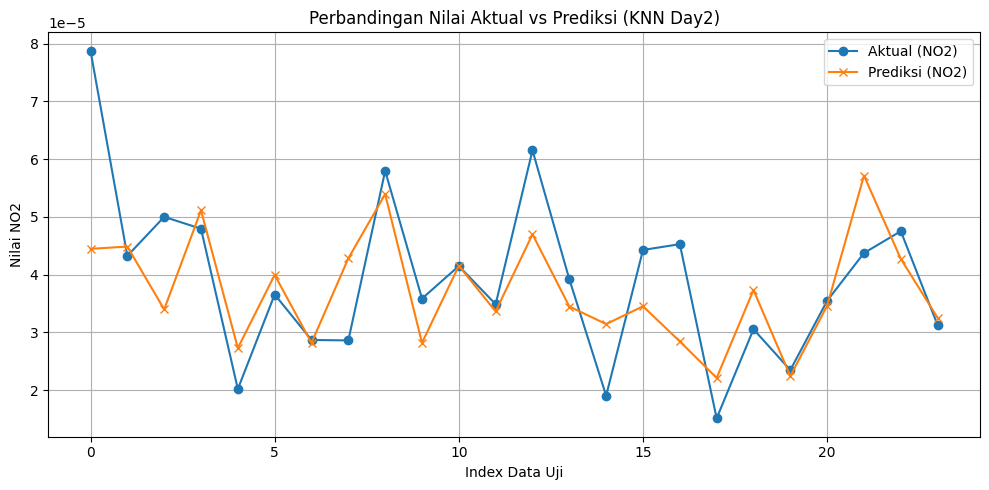

In [70]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Aktual (NO2)", marker='o')
plt.plot(day2_predict, label="Prediksi (NO2)", marker='x')

plt.title("Perbandingan Nilai Aktual vs Prediksi (KNN Day2)")
plt.xlabel("Index Data Uji")
plt.ylabel("Nilai NO2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Modeling Data Multi-step Forecasting t1, t2

In [71]:
X = day2_multi[['t1', 't2']]              
y = day2_multi[['NO2_t+1', 'NO2_t+2']]          

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsRegressor(n_neighbors=6)
knn.fit(X_train_scaled, y_train)
day2_predict = knn.predict(X_test_scaled)
r2_day2 = r2_score(y_test, day2_predict)
mse_day2 = mean_squared_error(y_test, day2_predict)

mape_day2_multi = mean_absolute_percentage_error(y_test, day2_predict)

print("MAPE: {:.2f}%".format(mape_day2 * 100))
print("MSE:", mse_day2)
print("R2:", r2_day2)

result = pd.DataFrame(day2_predict, columns=['Pred_NO2_t+1', 'Pred_NO2_t+2'])
result['Actual_NO2_t+1'] = y_test['NO2_t+1'].values
result['Actual_NO2_t+2'] = y_test['NO2_t+2'].values
result.head()

MAPE: 20.57%
MSE: 1.2338818383031345e-10
R2: 0.217905152219647


,Pred_NO2_t+1,Pred_NO2_t+2,Actual_NO2_t+1,Actual_NO2_t+2
0,0.000051,0.000046,0.000052,0.000040
1,0.000036,0.000042,0.000032,0.000044
2,0.000038,0.000049,0.000061,0.000071
3,0.000050,0.000043,0.000034,0.000043
4,0.000029,0.000034,0.000021,0.000022


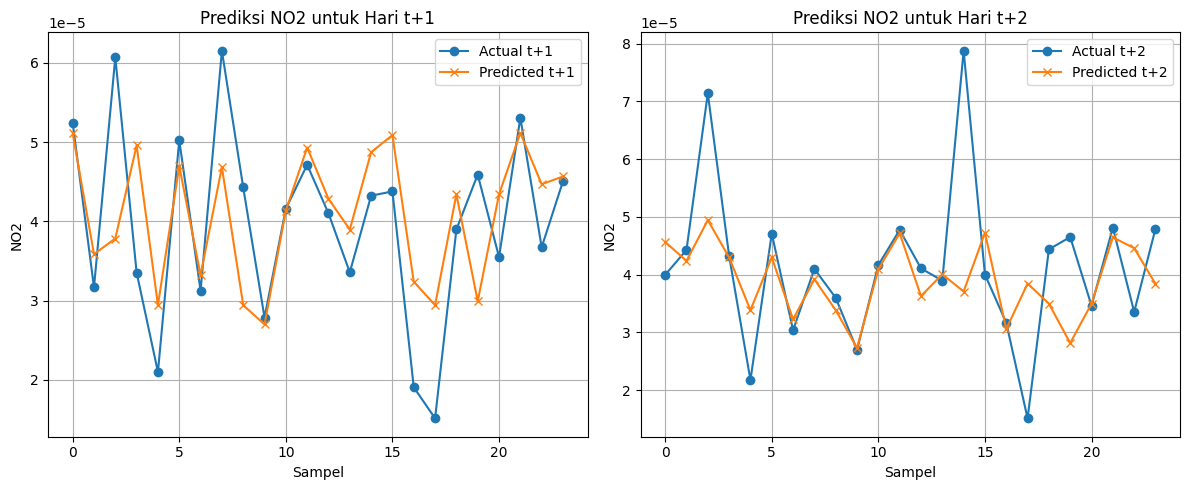

In [72]:
# Buat figure
plt.figure(figsize=(12, 5))

# Grafik 1: Prediksi t+1
plt.subplot(1, 2, 1)
plt.plot(result['Actual_NO2_t+1'].values, label='Actual t+1', marker='o')
plt.plot(result['Pred_NO2_t+1'].values, label='Predicted t+1', marker='x')
plt.title('Prediksi NO2 untuk Hari t+1')
plt.xlabel('Sampel')
plt.ylabel('NO2')
plt.legend()
plt.grid(True)

# Grafik 2: Prediksi t+2
plt.subplot(1, 2, 2)
plt.plot(result['Actual_NO2_t+2'].values, label='Actual t+2', marker='o')
plt.plot(result['Pred_NO2_t+2'].values, label='Predicted t+2', marker='x')
plt.title('Prediksi NO2 untuk Hari t+2')
plt.xlabel('Sampel')
plt.ylabel('NO2')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Modeling Data t1, t2, t3

In [73]:
X = day3.drop(columns=['NO2'])
y = day3['NO2']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsRegressor(n_neighbors=6)
knn.fit(X_train_scaled, y_train)
day3_predict = knn.predict(X_test_scaled)
r2_day3 = r2_score(y_test, day3_predict)
mse_day3 = mean_squared_error(y_test, day3_predict)

mape_day3 = mean_absolute_percentage_error(y_test, day3_predict)

print("MAPE: {:.2f}%".format(mape_day3 * 100))
print("MSE:", mse_day3)
print("R2:", r2_day3)

MAPE: 18.10%
MSE: 6.433889884475998e-11
R2: 0.5274650856138315


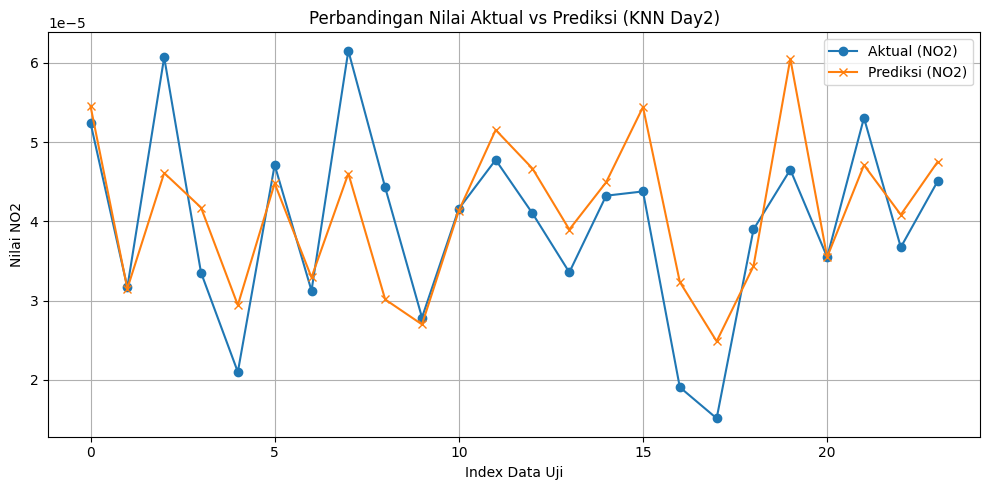

In [74]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Aktual (NO2)", marker='o')
plt.plot(day3_predict, label="Prediksi (NO2)", marker='x')

plt.title("Perbandingan Nilai Aktual vs Prediksi (KNN Day2)")
plt.xlabel("Index Data Uji")
plt.ylabel("Nilai NO2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Modeling Data Multi-step Forecasting t1, t2, t3

In [75]:
X = day3_multi[['t1', 't2', 't3']]              
y = day3_multi[['NO2_t+1', 'NO2_t+2']]          

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsRegressor(n_neighbors=6)
knn.fit(X_train_scaled, y_train)
day3_predict = knn.predict(X_test_scaled)
r2_day3 = r2_score(y_test, day3_predict)
mse_day3 = mean_squared_error(y_test, day3_predict)

mape_day3_multi = mean_absolute_percentage_error(y_test, day3_predict)

print("MAPE: {:.2f}%".format(mape_day3 * 100))
print("MSE:", mse_day3)
print("R2:", r2_day3)

result = pd.DataFrame(day3_predict, columns=['Pred_NO2_t+1', 'Pred_NO2_t+2'])
result['Actual_NO2_t+1'] = y_test['NO2_t+1'].values
result['Actual_NO2_t+2'] = y_test['NO2_t+2'].values
result.head()

MAPE: 18.10%
MSE: 1.9061168383302914e-10
R2: 0.008788579815451558


,Pred_NO2_t+1,Pred_NO2_t+2,Actual_NO2_t+1,Actual_NO2_t+2
0,0.000050,0.000043,0.000034,0.000043
1,0.000053,0.000045,0.000071,0.000082
2,0.000038,0.000036,0.000048,0.000065
3,0.000041,0.000040,0.000079,0.000044
4,0.000040,0.000037,0.000041,0.000041


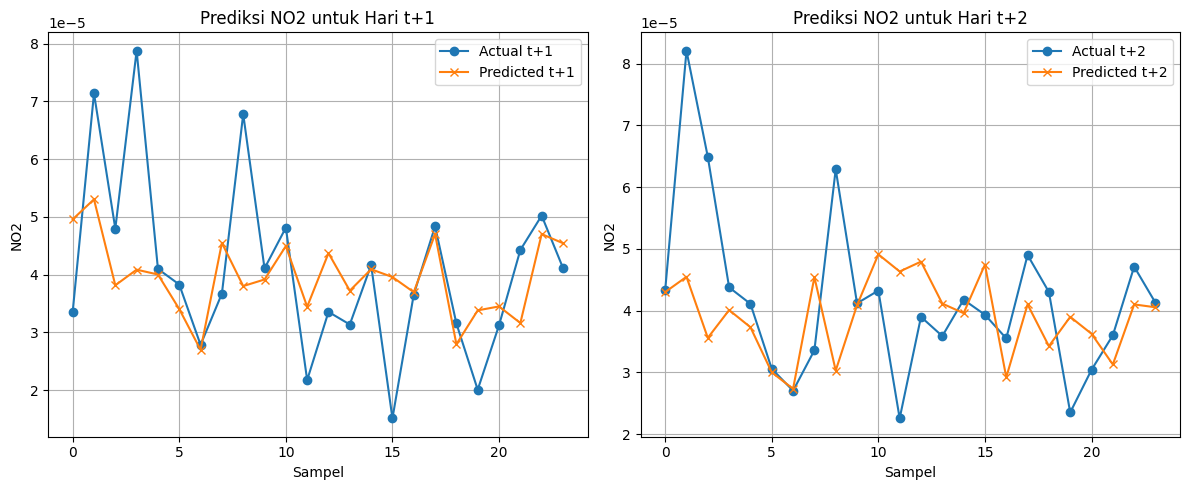

In [76]:
# Buat figure
plt.figure(figsize=(12, 5))

# Grafik 1: Prediksi t+1
plt.subplot(1, 2, 1)
plt.plot(result['Actual_NO2_t+1'].values, label='Actual t+1', marker='o')
plt.plot(result['Pred_NO2_t+1'].values, label='Predicted t+1', marker='x')
plt.title('Prediksi NO2 untuk Hari t+1')
plt.xlabel('Sampel')
plt.ylabel('NO2')
plt.legend()
plt.grid(True)

# Grafik 2: Prediksi t+2
plt.subplot(1, 2, 2)
plt.plot(result['Actual_NO2_t+2'].values, label='Actual t+2', marker='o')
plt.plot(result['Pred_NO2_t+2'].values, label='Predicted t+2', marker='x')
plt.title('Prediksi NO2 untuk Hari t+2')
plt.xlabel('Sampel')
plt.ylabel('NO2')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Modeling Data t1, t2, t3, t4

In [77]:
X = day4.drop(columns=['NO2'])
y = day4['NO2']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
day4_predict = knn.predict(X_test_scaled)
r2_day4 = r2_score(y_test, day4_predict)
mse_day4 = mean_squared_error(y_test, day4_predict)
mape_day4 = mean_absolute_percentage_error(y_test, day4_predict)

print("MAPE: {:.2f}%".format(mape_day4 * 100))

print("MSE:", mse_day4)
print("R2:", r2_day4)

MAPE: 20.26%
MSE: 1.636020840797285e-10
R2: 0.05386850429585299


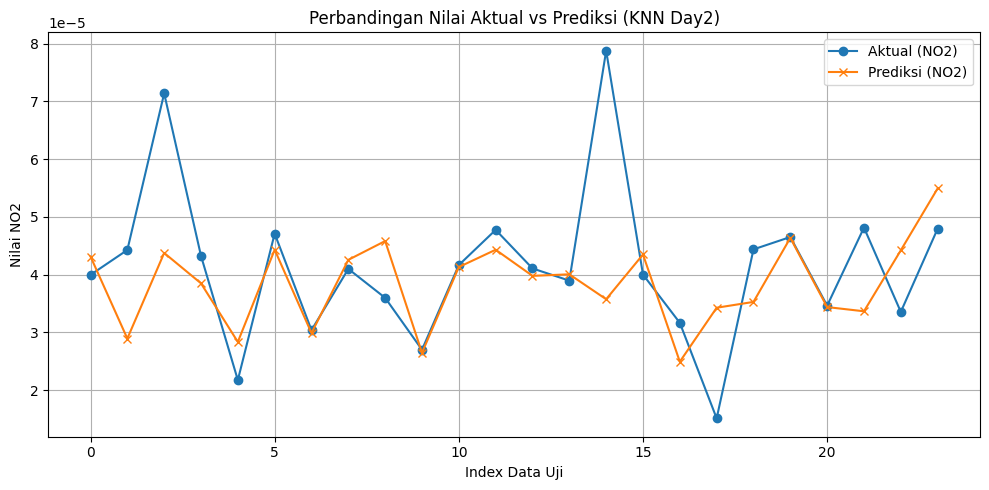

In [78]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Aktual (NO2)", marker='o')
plt.plot(day4_predict, label="Prediksi (NO2)", marker='x')

plt.title("Perbandingan Nilai Aktual vs Prediksi (KNN Day2)")
plt.xlabel("Index Data Uji")
plt.ylabel("Nilai NO2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Modeling Data Multi-step Forecasting t1, t2, t3, t4

In [79]:
X = day4_multi[['t1', 't2', 't3', 't4']]              
y = day4_multi[['NO2_t+1', 'NO2_t+2']]          

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(X_train_scaled, y_train)
day4_predict = knn.predict(X_test_scaled)
r2_day4 = r2_score(y_test, day4_predict)
mse_day4 = mean_squared_error(y_test, day4_predict)

mape_day4_multi = mean_absolute_percentage_error(y_test, day4_predict)

print("MAPE: {:.2f}%".format(mape_day4 * 100))
print("MSE:", mse_day4)
print("R2:", r2_day4)

result = pd.DataFrame(day4_predict, columns=['Pred_NO2_t+1', 'Pred_NO2_t+2'])
result['Actual_NO2_t+1'] = y_test['NO2_t+1'].values
result['Actual_NO2_t+2'] = y_test['NO2_t+2'].values
result.head()

MAPE: 20.26%
MSE: 1.925452812901887e-10
R2: -0.12364624252547529


,Pred_NO2_t+1,Pred_NO2_t+2,Actual_NO2_t+1,Actual_NO2_t+2
0,0.000031,0.000028,0.000038,0.000038
1,0.000039,0.000038,0.000082,0.000064
2,0.000050,0.000040,0.000044,0.000034
3,0.000054,0.000040,0.000043,0.000079
4,0.000036,0.000043,0.000041,0.000041


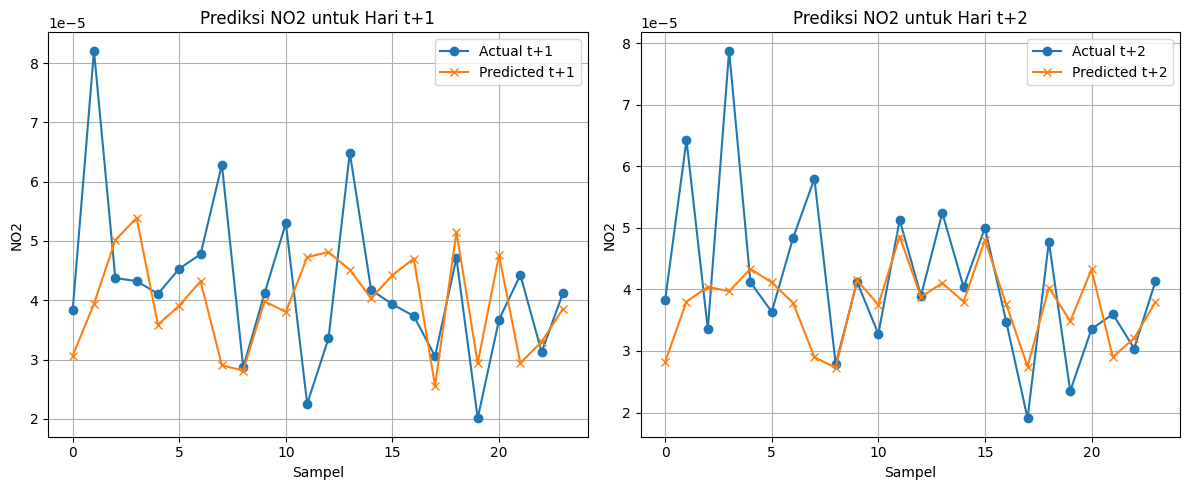

In [80]:
# Buat figure
plt.figure(figsize=(12, 5))

# Grafik 1: Prediksi t+1
plt.subplot(1, 2, 1)
plt.plot(result['Actual_NO2_t+1'].values, label='Actual t+1', marker='o')
plt.plot(result['Pred_NO2_t+1'].values, label='Predicted t+1', marker='x')
plt.title('Prediksi NO2 untuk Hari t+1')
plt.xlabel('Sampel')
plt.ylabel('NO2')
plt.legend()
plt.grid(True)

# Grafik 2: Prediksi t+2
plt.subplot(1, 2, 2)
plt.plot(result['Actual_NO2_t+2'].values, label='Actual t+2', marker='o')
plt.plot(result['Pred_NO2_t+2'].values, label='Predicted t+2', marker='x')
plt.title('Prediksi NO2 untuk Hari t+2')
plt.xlabel('Sampel')
plt.ylabel('NO2')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Modeling Data t1, t2, t3, t4, t5

In [81]:
X = day5.drop(columns=['NO2'])
y = day5['NO2']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsRegressor(n_neighbors=14)
knn.fit(X_train_scaled, y_train)
day5_predict = knn.predict(X_test_scaled)
r2_day5 = r2_score(y_test, day5_predict)
mse_day5 = mean_squared_error(y_test, day5_predict)
mape_day5 = mean_absolute_percentage_error(y_test, day5_predict)

print("MAPE: {:.2f}%".format(mape_day5 * 100))
print("MSE:", mse_day5)
print("R2:", r2_day5)

MAPE: 14.85%
MSE: 1.0311452662792994e-10
R2: 0.3907964342150523


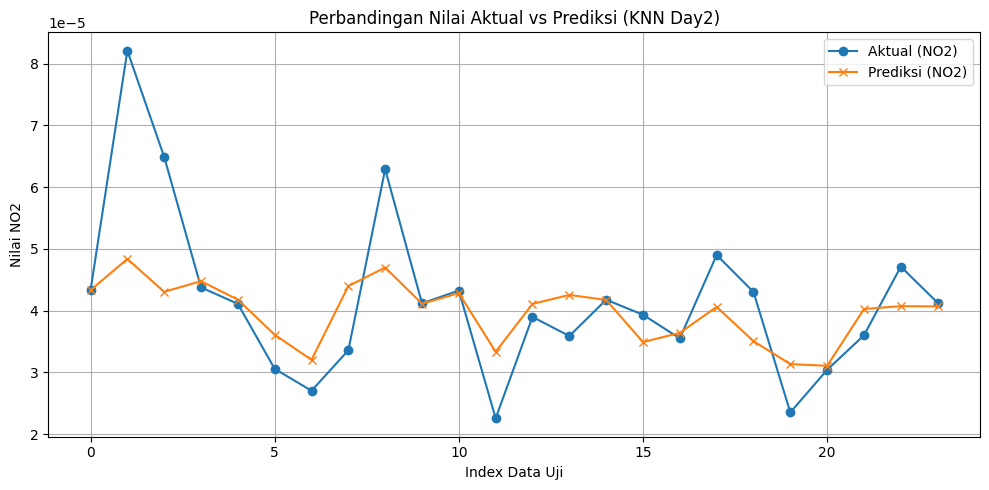

In [82]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Aktual (NO2)", marker='o')
plt.plot(day5_predict, label="Prediksi (NO2)", marker='x')

plt.title("Perbandingan Nilai Aktual vs Prediksi (KNN Day2)")
plt.xlabel("Index Data Uji")
plt.ylabel("Nilai NO2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Modeling Data Multi-step Forecasting t1, t2, t3, t4, t5

In [83]:
X = day5_multi[['t1', 't2', 't3', 't4', 't5']]              
y = day5_multi[['NO2_t+1', 'NO2_t+2']]          

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsRegressor(n_neighbors=4)
knn.fit(X_train_scaled, y_train)
day5_predict = knn.predict(X_test_scaled)
r2_day5 = r2_score(y_test, day5_predict)
mse_day5 = mean_squared_error(y_test, day5_predict)

mape_day5_multi = mean_absolute_percentage_error(y_test, day5_predict)

print("MAPE: {:.2f}%".format(mape_day5 * 100))
print("MSE:", mse_day5)
print("R2:", r2_day5)

result = pd.DataFrame(day5_predict, columns=['Pred_NO2_t+1', 'Pred_NO2_t+2'])
result['Actual_NO2_t+1'] = y_test['NO2_t+1'].values
result['Actual_NO2_t+2'] = y_test['NO2_t+2'].values
result.head()

MAPE: 14.85%
MSE: 7.917259650803388e-11
R2: 0.42603492256705594


,Pred_NO2_t+1,Pred_NO2_t+2,Actual_NO2_t+1,Actual_NO2_t+2
0,0.000042,0.000038,0.000038,0.000038
1,0.000046,0.000044,0.000064,0.000046
2,0.000045,0.000047,0.000079,0.000044
3,0.000027,0.000029,0.000029,0.000028
4,0.000042,0.000042,0.000041,0.000041


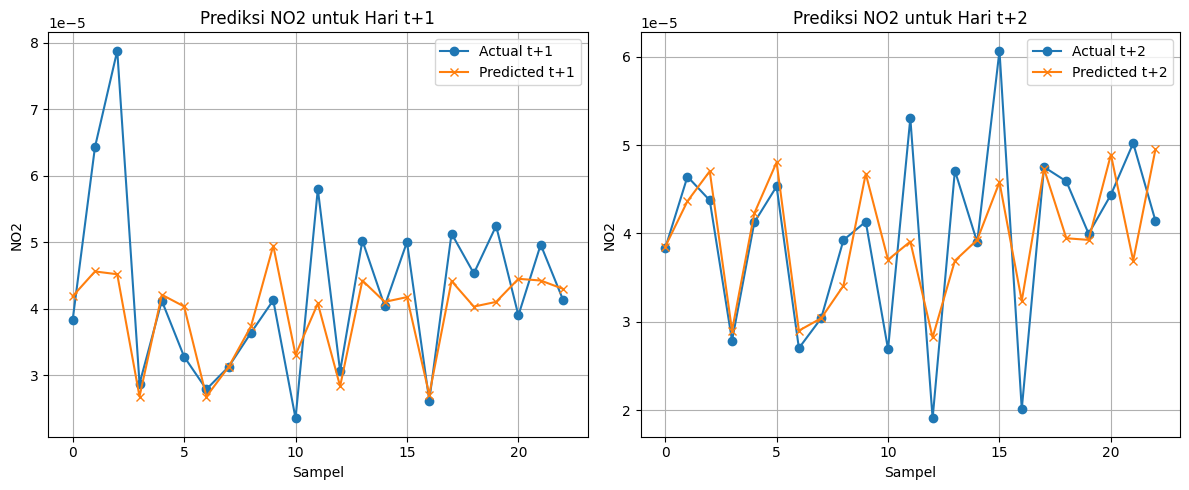

In [84]:
# Buat figure
plt.figure(figsize=(12, 5))

# Grafik 1: Prediksi t+1
plt.subplot(1, 2, 1)
plt.plot(result['Actual_NO2_t+1'].values, label='Actual t+1', marker='o')
plt.plot(result['Pred_NO2_t+1'].values, label='Predicted t+1', marker='x')
plt.title('Prediksi NO2 untuk Hari t+1')
plt.xlabel('Sampel')
plt.ylabel('NO2')
plt.legend()
plt.grid(True)

# Grafik 2: Prediksi t+2
plt.subplot(1, 2, 2)
plt.plot(result['Actual_NO2_t+2'].values, label='Actual t+2', marker='o')
plt.plot(result['Pred_NO2_t+2'].values, label='Predicted t+2', marker='x')
plt.title('Prediksi NO2 untuk Hari t+2')
plt.xlabel('Sampel')
plt.ylabel('NO2')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [66]:
import pickle

# simpan model
with open("../Aplikasi/Aplikasi Prediksi NO2/model/model_knn_day5.pkl", "wb") as f:
    pickle.dump(knn, f)

# simpan normalisasi
with open("../Aplikasi/Aplikasi Prediksi NO2/model/scaler_day5.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [6]:
X = day5_multi_new[['t1', 't2', 't3', 't4', 't5']]              
y = day5_multi_new[['NO2_t+1', 'NO2_t+2']]          

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsRegressor(n_neighbors=4)
knn.fit(X_train_scaled, y_train)
day5_predict = knn.predict(X_test_scaled)
r2_day5 = r2_score(y_test, day5_predict)
mse_day5 = mean_squared_error(y_test, day5_predict)

mape_day5_multi = mean_absolute_percentage_error(y_test, day5_predict)

print("MAPE: {:.2f}%".format(mape_day5_multi * 100))
print("MSE:", mse_day5)
print("R2:", r2_day5)

result = pd.DataFrame(day5_predict, columns=['Pred_NO2_t+1', 'Pred_NO2_t+2'])
result['Actual_NO2_t+1'] = y_test['NO2_t+1'].values
result['Actual_NO2_t+2'] = y_test['NO2_t+2'].values
result.head()

MAPE: 27.38%
MSE: 1.2216530658804411e-10
R2: 0.10275429869930225


,Pred_NO2_t+1,Pred_NO2_t+2,Actual_NO2_t+1,Actual_NO2_t+2
0,0.000042,0.000040,0.000023,0.000045
1,0.000046,0.000043,0.000050,0.000061
2,0.000038,0.000034,0.000044,0.000034
3,0.000044,0.000048,0.000033,0.000039
4,0.000040,0.000036,0.000019,0.000020


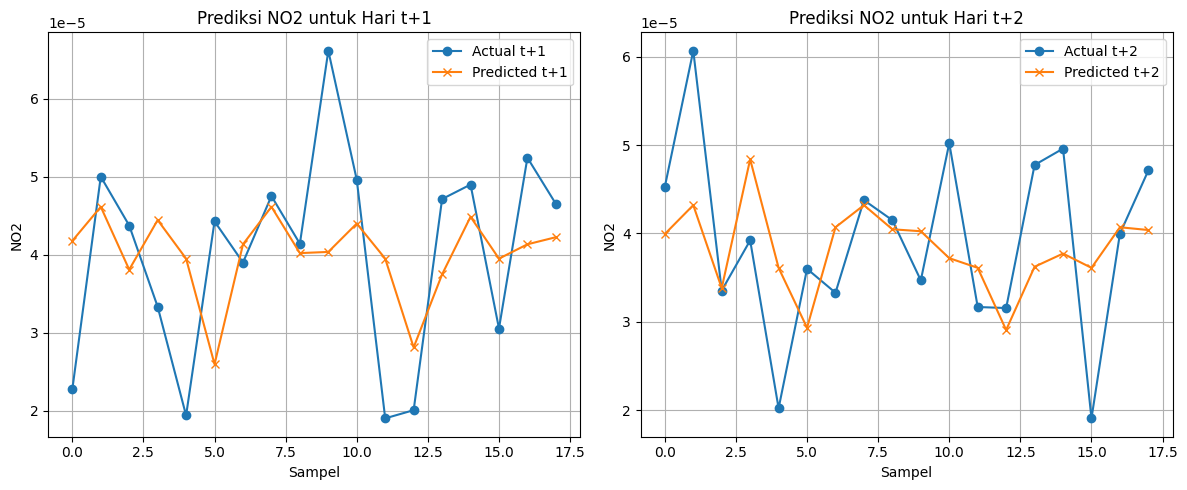

In [7]:
# Buat figure
plt.figure(figsize=(12, 5))

# Grafik 1: Prediksi t+1
plt.subplot(1, 2, 1)
plt.plot(result['Actual_NO2_t+1'].values, label='Actual t+1', marker='o')
plt.plot(result['Pred_NO2_t+1'].values, label='Predicted t+1', marker='x')
plt.title('Prediksi NO2 untuk Hari t+1')
plt.xlabel('Sampel')
plt.ylabel('NO2')
plt.legend()
plt.grid(True)

# Grafik 2: Prediksi t+2
plt.subplot(1, 2, 2)
plt.plot(result['Actual_NO2_t+2'].values, label='Actual t+2', marker='o')
plt.plot(result['Pred_NO2_t+2'].values, label='Predicted t+2', marker='x')
plt.title('Prediksi NO2 untuk Hari t+2')
plt.xlabel('Sampel')
plt.ylabel('NO2')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Perbandingan MAPE Single Forcasting Berdasarkan Banyak Lag Hari yang digunakan

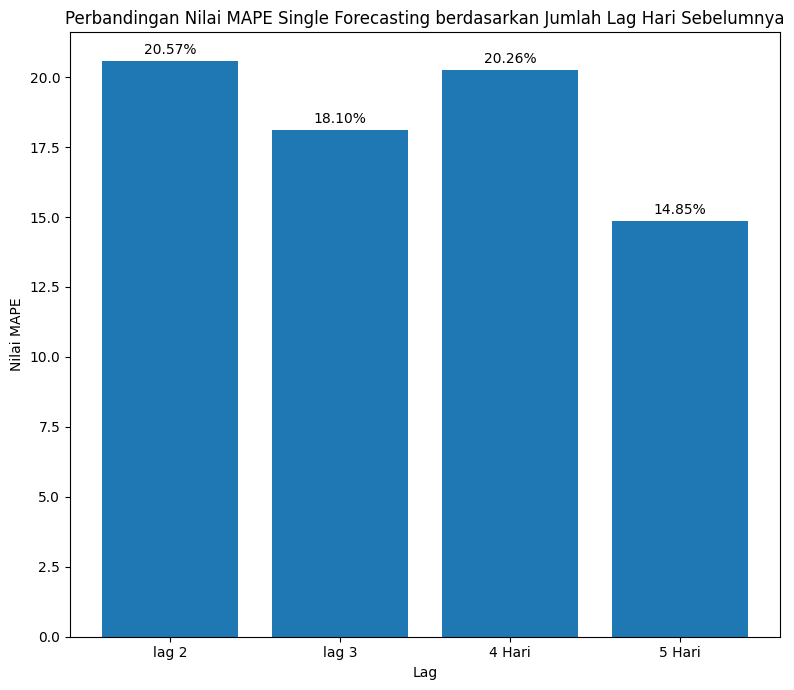

In [87]:
x = ['lag 2', 'lag 3', '4 Hari', '5 Hari']
y = [mape_day2, mape_day3, mape_day4, mape_day5]

y_percent = [v * 100 for v in y]

fig, ax = plt.subplots(figsize=(8, 7))
bars = ax.bar(x, y_percent)

ax.set_title("Perbandingan Nilai MAPE Single Forecasting berdasarkan Jumlah Lag Hari Sebelumnya")
ax.set_xlabel("Lag")
ax.set_ylabel("Nilai MAPE")

ax.bar_label(bars, fmt='%.2f%%', padding=3)

plt.tight_layout()
plt.show()


## Perbandingan MAPE Multi Forcasting Berdasarkan Banyak Lag Hari yang digunakan

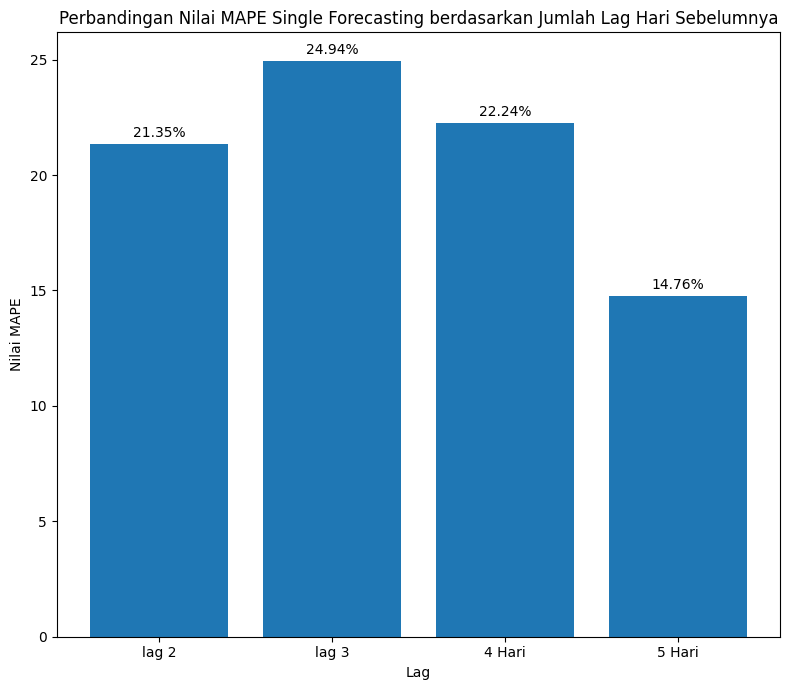

In [88]:
x = ['lag 2', 'lag 3', '4 Hari', '5 Hari']
y = [mape_day2_multi, mape_day3_multi, mape_day4_multi, mape_day5_multi]

y_percent = [v * 100 for v in y]

fig, ax = plt.subplots(figsize=(8, 7))
bars = ax.bar(x, y_percent)

ax.set_title("Perbandingan Nilai MAPE Single Forecasting berdasarkan Jumlah Lag Hari Sebelumnya")
ax.set_xlabel("Lag")
ax.set_ylabel("Nilai MAPE")

ax.bar_label(bars, fmt='%.2f%%', padding=3)

plt.tight_layout()
plt.show()


### Hasil Aplikasi

[Klik di sini untuk membuka aplikasi](https://semarang-no2-prediction.streamlit.app/)